In [11]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from utils.model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [12]:
train_loader = ImagenetteDataLoader(
    root_path='notebooks/input/imagenette2',
    split='train',
    target_size=(300, 300)
)

images, labels = train_loader.load_images()
images.shape, labels.shape

((9469, 3, 300, 300), (9469,))

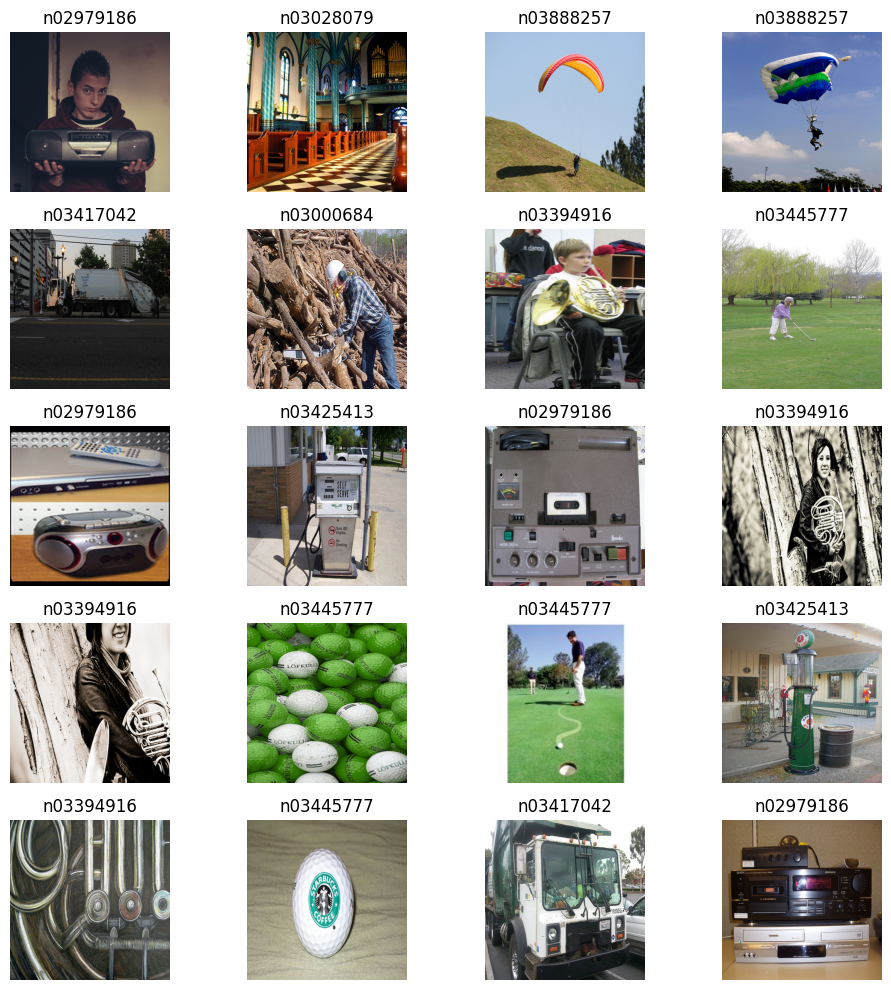

In [8]:
random_indices = cp.random.randint(0, len(images), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [14]:
layer_definitions = [
    {'type': 'ReLU', 'input_size': 300, 'num_neurons': 300},
    {'type': 'ReLU', 'input_size': 300, 'num_neurons': 200},
    {'type': 'ReLU', 'input_size': 200, 'num_neurons': 100},
    {'type': 'ReLU', 'input_size': 100, 'num_neurons': 50},
    {'Sigmoid': 'ReLU', 'input_size': 20, 'num_neurons': 1}
]

network = Network(layer_definitions=layer_definitions)

In [15]:
network.describe()

Network Architecture

Layer 1: ReluLayer
  Weights Shape: (300, 300) | Biases Shape: (300,)
  Parameters: 90,300

Layer 2: ReluLayer
  Weights Shape: (300, 200) | Biases Shape: (200,)
  Parameters: 60,200

Layer 3: ReluLayer
  Weights Shape: (200, 100) | Biases Shape: (100,)
  Parameters: 20,100

Layer 4: ReluLayer
  Weights Shape: (100, 50) | Biases Shape: (50,)
  Parameters: 5,050

Layer 5: Layer
  Weights Shape: (20, 1) | Biases Shape: (1,)
  Parameters: 21

Total Parameters: 175,671
